# End-to-End Hierarchical IDS System Execution

This notebook executes the final hierarchical IDS end-to-end on a held-out test set.
All models, thresholds, and safety parameters are fixed based on prior validation analysis.
The test split is recreated deterministically using the same procedure as Notebook 1.
No training, tuning, or threshold optimisation is performed here.


In [9]:
# -------------------------------
# 0. LOOKUP Dictionary
# -------------------------------
SCENARIO_LOOKUP = {
    # Natural Faults (1–6)
    1: "Fault L1 (10–19%)",
    2: "Fault L1 (20–79%)",
    3: "Fault L1 (80–90%)",
    4: "Fault L2 (10–19%)",
    5: "Fault L2 (20–79%)",
    6: "Fault L2 (80–90%)",

    # Maintenance (13–14)
    13: "Line Maintenance L1",
    14: "Line Maintenance L2",

    # Data Injection Attacks (7–12)
    7:  "Data Injection: L1 Fault 10–19% with tripping",
    8:  "Data Injection: L1 Fault 20–79% with tripping",
    9:  "Data Injection: L1 Fault 80–90% with tripping",
    10: "Data Injection: L2 Fault 10–19% with tripping",
    11: "Data Injection: L2 Fault 20–79% with tripping",
    12: "Data Injection: L2 Fault 80–90% with tripping",

    # Remote Tripping Attacks (15–20)
    15: "Remote Tripping: Command Injection R1",
    16: "Remote Tripping: Command Injection R2",
    17: "Remote Tripping: Command Injection R3",
    18: "Remote Tripping: Command Injection R4",
    19: "Remote Tripping: Command Injection R1 & R2",
    20: "Remote Tripping: Command Injection R3 & R4",

    # Relay Setting Change (21–30)
    21: "Relay Setting Change: R1 disabled (L1 10–19% fault)",
    22: "Relay Setting Change: R1 disabled (L1 20–90% fault)",
    23: "Relay Setting Change: R2 disabled (L1 10–49% fault)",
    24: "Relay Setting Change: R2 disabled (L1 50–79% fault)",
    25: "Relay Setting Change: R2 disabled (L1 80–90% fault)",
    26: "Relay Setting Change: R3 disabled (L2 10–19% fault)",
    27: "Relay Setting Change: R3 disabled (L2 20–49% fault)",
    28: "Relay Setting Change: R3 disabled (L2 50–90% fault)",
    29: "Relay Setting Change: R4 disabled (L2 10–79% fault)",
    30: "Relay Setting Change: R4 disabled (L2 80–90% fault)",

    # Relay Setting Change (two relays + fault)
    35: "Relay Setting Change: R1 & R2 disabled (L1 10–49% fault)",
    36: "Relay Setting Change: R1 & R2 disabled (L1 50–90% fault)",
    37: "Relay Setting Change: R3 & R4 disabled (L1 10–49% fault)",
    38: "Relay Setting Change: R3 & R4 disabled (L1 50–90% fault)",

    # Relay Setting Change (two relays + maintenance)
    39: "Relay Setting Change: R1 & R2 disabled during maintenance",
    40: "Relay Setting Change: R1 & R2 disabled during maintenance",

    # Normal Operation
    41: "Normal Operation (no disturbances)"
}

DI_NAMES = {
    7: "DI: Fault 10–19% L1",
    8: "DI: Fault 20–79% L1",
    9: "DI: Fault 80–90% L1",
    10: "DI: Fault 10–19% L2",
    11: "DI: Fault 20–79% L2",
    12: "DI: Fault 80–90% L2"
}

RT_NAMES = {
    15: "Remote Trip: Cmd R1",
    16: "Remote Trip: Cmd R2",
    17: "Remote Trip: Cmd R3",
    18: "Remote Trip: Cmd R4",
    19: "Remote Trip: Cmd R1 & R2",
    20: "Remote Trip: Cmd R3 & R4"
}

RSC_NAMES = {
    21: "RSC: L1 R1 Disabled (10–19%)",
    22: "RSC: L1 R1 Disabled (20–90%)",
    23: "RSC: L1 R2 Disabled (10–49%)", 
    24: "RSC: L1 R2 Disabled (50–79%)",
    25: "RSC: L1 R2 Disabled (80–90%)",
    26: "RSC: L2 R3 Disabled (10–19%)",
    27: "RSC: L2 R3 Disabled (20–49%)",
    28: "RSC: L2 R3 Disabled (50–90%)",
    29: "RSC: L2 R4 Disabled (10–79%)",
    30: "RSC: L2 R4 Disabled (80–90%)",
    35: "RSC: L1 R1&R2 Disabled (10–49%)",
    36: "RSC: L1 R1&R2 Disabled (50–90%)",
    37: "RSC: L1 R3&R4 Disabled (10–49%)",
    38: "RSC: L1 R3&R4 Disabled (50–90%)",
    39: "RSC: L1 Maint R1&R2 Disabled",
    40: "RSC: L1 Maint R1&R2 Disabled"
}


In [10]:
import numpy as np
import pandas as pd
import joblib
from tqdm.auto import tqdm

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score
)

import warnings
warnings.filterwarnings("ignore", category=UserWarning)


In [11]:
# ------------------------------------------------------------
# Load full dataset (same source as Notebook 1)
# ------------------------------------------------------------
DATA_PATH = "../data/merged/multi_class_dataset_clean_FULL.csv"

df = pd.read_csv(DATA_PATH)

FEATURE_COLS = [
    c for c in df.columns
    if c not in ["marker", "label", "label_name"]
]

X_all = df[FEATURE_COLS]
y_marker = df["marker"]

# ------------------------------------------------------------
# Binary labels for M1 (same mapping as Notebook 1)
# ------------------------------------------------------------
NON_ATTACK_IDS = [1,2,3,4,5,6,13,14,41]

def map_M1(marker):
    return 1 if marker in NON_ATTACK_IDS else 0  # 1=Non-attack, 0=Attack

y_M1 = y_marker.apply(map_M1)

# ------------------------------------------------------------
# Recreate test split deterministically
# ------------------------------------------------------------
X_temp, X_test, y_temp, y_test = train_test_split(
    X_all,
    y_M1,
    test_size=0.20,
    random_state=42,
    stratify=y_M1
)

is_attack_test = (y_test == 0)

print("Test samples:", len(X_test))
print("Attack fraction:", is_attack_test.mean())


Test samples: 15676
Attack fraction: 0.7101939270221995


In [12]:
# ------------------------------------------------------------
# Load all frozen models
# ------------------------------------------------------------
M1 = joblib.load("../models/M1.joblib")
M2 = joblib.load("../models/M2.joblib")
M3 = joblib.load("../models/M3.joblib")
M4 = joblib.load("../models/M4.joblib")
M5 = joblib.load("../models/M5.joblib")
M6 = joblib.load("../models/M6.joblib")

ATTACK_LABEL_IDX = 0  # attack index in M1.predict_proba

print("Models M1–M6 loaded.")


Models M1–M6 loaded.


In [13]:

# ============================================================
# Feature Name Mapping (Human Readable)
# ============================================================

def readable_feature(name):

    relay = name.split("-")[0]

    # ---------------- Voltage Magnitude ----------------
    if "PM1:V" in name:
        return f"{relay} Phase A Voltage Magnitude"

    if "PM2:V" in name:
        return f"{relay} Phase B Voltage Magnitude"

    if "PM3:V" in name:
        return f"{relay} Phase C Voltage Magnitude"

    # ---------------- Current Magnitude ----------------
    if "PM4:I" in name:
        return f"{relay} Phase A Current Magnitude"

    if "PM5:I" in name:
        return f"{relay} Phase B Current Magnitude"

    if "PM6:I" in name:
        return f"{relay} Phase C Current Magnitude"

    # ---------------- Voltage Angle ----------------
    if "PA1:VH" in name:
        return f"{relay} Phase A Voltage Angle"

    if "PA2:VH" in name:
        return f"{relay} Phase B Voltage Angle"

    if "PA3:VH" in name:
        return f"{relay} Phase C Voltage Angle"

    # ---------------- Current Angle ----------------
    if "PA4:IH" in name:
        return f"{relay} Phase A Current Angle"

    if "PA5:IH" in name:
        return f"{relay} Phase B Current Angle"

    if "PA6:IH" in name:
        return f"{relay} Phase C Current Angle"

    # ---------------- Sequence Components ----------------
    if "PM7:V" in name:
        return f"{relay} Positive Sequence Voltage"

    if "PM8:V" in name:
        return f"{relay} Negative Sequence Voltage"

    if "PM9:V" in name:
        return f"{relay} Zero Sequence Voltage"

    if "PM10:I" in name:
        return f"{relay} Positive Sequence Current"

    if "PM11:I" in name:
        return f"{relay} Negative Sequence Current"

    if "PM12:I" in name:
        return f"{relay} Zero Sequence Current"

    # ---------------- Frequency ----------------
    if ":F" in name:
        return f"{relay} Frequency"

    if ":DF" in name:
        return f"{relay} Frequency Change Rate"

    # ---------------- Impedance ----------------
    if ":Z" in name:
        return f"{relay} Apparent Impedance"

    if ":ZH" in name:
        return f"{relay} Impedance Angle"

    # ---------------- Status ----------------
    if ":S" in name:
        return f"{relay} Relay Status"

    return name

M1 Attack Detector → No feature importance available


M2 Non-Attack
R4 Phase B Voltage Magnitude : 0.0498
R4 Positive Sequence Voltage : 0.0308
R2 Apparent Impedance : 0.0273
R3 Apparent Impedance : 0.0242
R1 Phase B Voltage Magnitude : 0.0226
R4 Phase C Voltage Magnitude : 0.0209
R2 Phase C Voltage Magnitude : 0.0199
R4 Phase A Voltage Magnitude : 0.0195
R4 Apparent Impedance : 0.0191
R1 Apparent Impedance : 0.0172


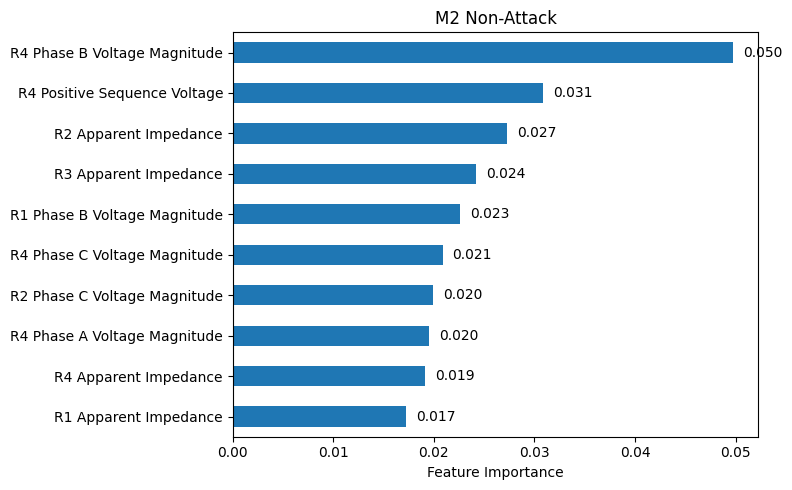


M3 Attack Family
R3 Phase B Voltage Magnitude : 0.0219
R1 Phase B Voltage Magnitude : 0.0208
R4 Phase B Voltage Magnitude : 0.0190
R1 Phase B Current Magnitude : 0.0150
R2 Phase B Current Magnitude : 0.0149
R3 Phase B Current Magnitude : 0.0147
R4 Phase B Current Magnitude : 0.0147
R2 Phase B Current Angle : 0.0143
R3 Phase B Current Angle : 0.0142
R4 Phase B Current Angle : 0.0140


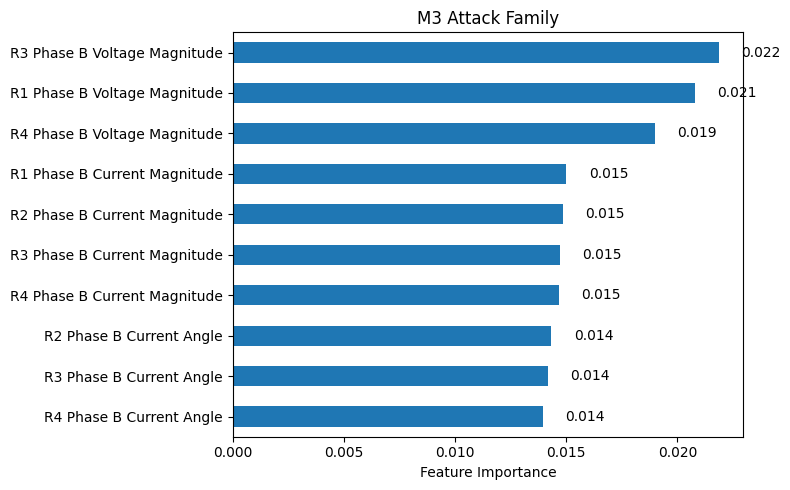


M4 Data Injection
R4 Phase B Voltage Magnitude : 0.0393
R2 Phase C Voltage Magnitude : 0.0209
R4 Positive Sequence Voltage : 0.0203
R1 Phase B Voltage Magnitude : 0.0197
R2 Phase A Voltage Magnitude : 0.0171
R1 Phase B Voltage Angle : 0.0170
R4 Phase B Voltage Angle : 0.0160
R1 Phase B Current Magnitude : 0.0156
R2 Positive Sequence Voltage : 0.0156
R2 Phase B Current Magnitude : 0.0152


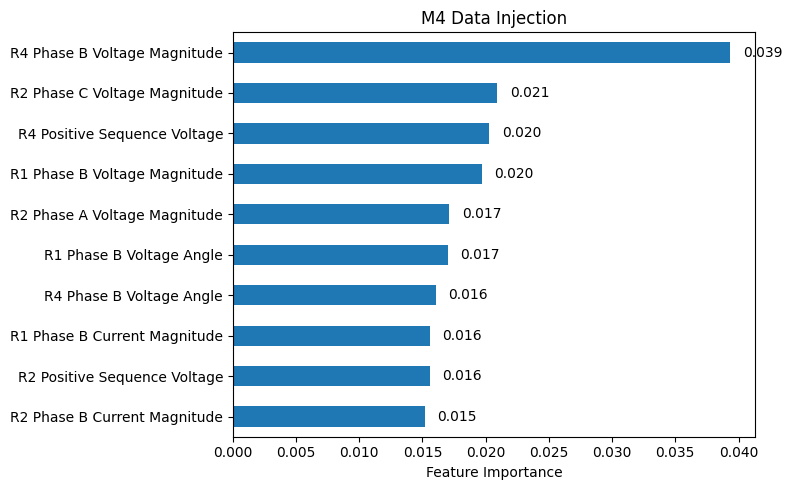


M5 Remote Tripping
R4 Phase B Voltage Magnitude : 0.0402
R2 Phase C Voltage Magnitude : 0.0218
R4 Positive Sequence Voltage : 0.0198
R2 Positive Sequence Voltage : 0.0178
R1 Phase B Voltage Magnitude : 0.0178
R1 Phase B Current Magnitude : 0.0176
R3 Phase B Current Magnitude : 0.0172
R2 Phase B Current Magnitude : 0.0169
R4 Phase B Current Magnitude : 0.0167
R2 Phase A Voltage Magnitude : 0.0167


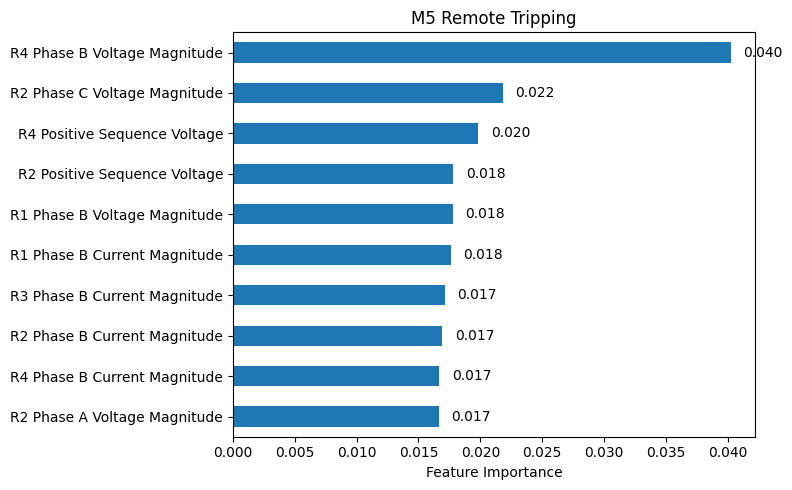


M6 Relay Setting Change
R1 Phase B Voltage Magnitude : 0.0335
R3 Phase B Voltage Magnitude : 0.0272
R4 Phase B Voltage Magnitude : 0.0221
R1 Phase B Current Magnitude : 0.0177
R3 Phase B Current Magnitude : 0.0176
R2 Phase B Current Magnitude : 0.0173
R4 Phase B Current Magnitude : 0.0173
R4 Positive Sequence Voltage : 0.0171
R2 Phase C Voltage Magnitude : 0.0152
R4 Phase C Voltage Angle : 0.0146


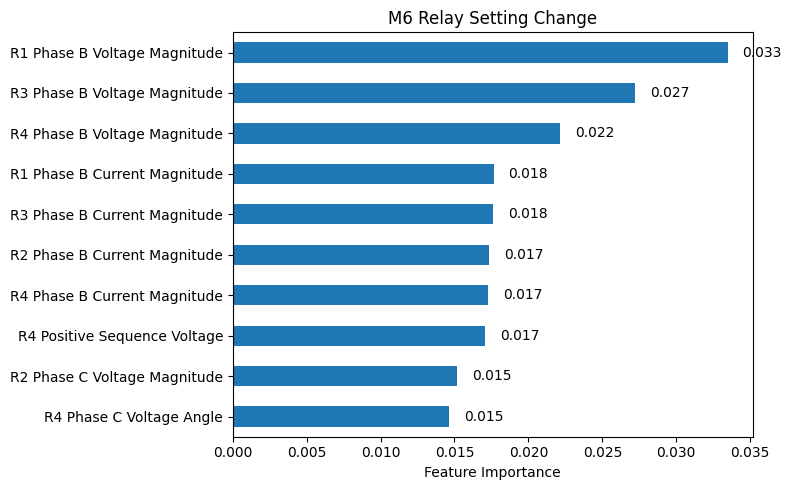

In [14]:
# ============================================================
# Feature Importance (List + Plot)
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

models = {
    "M1 Attack Detector": M1,
    "M2 Non-Attack": M2,
    "M3 Attack Family": M3,
    "M4 Data Injection": M4,
    "M5 Remote Tripping": M5,
    "M6 Relay Setting Change": M6
}

top_k = 10

for name, model in models.items():

    if not hasattr(model, "feature_importances_"):
        print(f"{name} → No feature importance available\n")
        continue

    importance = pd.Series(
        model.feature_importances_,
        index=FEATURE_COLS
    )

    top_features = importance.sort_values(ascending=False).head(top_k)

    # Convert to readable names
    readable = [readable_feature(f) for f in top_features.index]

    print("\n===============================")
    print(name)
    print("===============================")

    for f, v in zip(readable, top_features.values):
        print(f"{f} : {v:.4f}")

    # ---------- Plot ----------
    top_features.index = readable

    plt.figure(figsize=(8,5))

    ax = top_features.sort_values().plot(
        kind="barh"
    )

    plt.title(name)
    plt.xlabel("Feature Importance")

    # attach values
    for i, v in enumerate(top_features.sort_values()):
        ax.text(v + 0.001, i, f"{v:.3f}", va="center")

    plt.tight_layout()
    plt.show()

In [15]:
# ------------------------------------------------------------
# Fixed parameters from validation analysis
# ------------------------------------------------------------
TAU_GATE = 0.5311 
CONF_FALLBACK = 0.8100
SAFE_MARGIN = 0.0750


In [16]:
# ------------------------------------------------------------
# M2 label map (local index → non-attack family)
# ------------------------------------------------------------
# Used only for end-to-end inference output

M2_LABELS = {
0: "SLG Faults",
1: "Line Maintenance",
2: "Normal Operation"
}

# ------------------------------------------------------------
# Inverse maps: leaf index → real scenario ID (ATTACKS ONLY)
# ------------------------------------------------------------
# ------------------------------------------------------------
# Attack scenario IDs
# ------------------------------------------------------------

# Data Injection
DI_IDS = [7, 8, 9, 10, 11, 12]

# Remote Tripping
RT_IDS = [15, 16, 17, 18, 19, 20]

# Relay Setting Change
RSC_IDS = [
    21,22,23,24,25,26,27,28,29,30,
    35,36,37,38,39,40
]

M4_INV_MAP = {i: k for i, k in enumerate(DI_IDS)}
M5_INV_MAP = {i: k for i, k in enumerate(RT_IDS)}
M6_INV_MAP = {i: k for i, k in enumerate(RSC_IDS)}

In [17]:
# ============================================================
# Get Top Contributing Features
# ============================================================

def get_top_features(model, feature_names, k=3):

    if not hasattr(model, "feature_importances_"):
        return None

    importances = model.feature_importances_

    pairs = list(zip(feature_names, importances))

    pairs.sort(key=lambda x: x[1], reverse=True)

    top = pairs[:k]

    factors = [
        (readable_feature(feature), f"{importance*100:.1f}%")
        for feature, importance in top
    ]

    return factors

In [18]:
from tqdm import tqdm

def hierarchical_predict(X, y_true_marker=None):

    records = []

    # ✅ align features once
    X = X[FEATURE_COLS].copy()

    # ✅ precompute routing models
    m1_probs = M1.predict_proba(X)[:, ATTACK_LABEL_IDX]
    m3_all_probs = M3.predict_proba(X)

    # ============================================================
    # 🔥 CACHE EXPLAINABILITY (CRITICAL FIX)
    # ============================================================
    TOP_M2 = get_top_features(M2, FEATURE_COLS, k=3)
    TOP_M4 = get_top_features(M4, FEATURE_COLS, k=3)
    TOP_M5 = get_top_features(M5, FEATURE_COLS, k=3)
    TOP_M6 = get_top_features(M6, FEATURE_COLS, k=3)

    for i in tqdm(
        range(len(X)),
        desc="End-to-End IDS Inference",
        unit="sample",
        mininterval=1
    ):

        sample = X.iloc[[i]]
        p_attack = float(m1_probs[i])

        record = {
            "M1_conf": p_attack,
            "M3_conf": None,
            "M2_conf": None,
            "Leaf_model": None,
            "Leaf_conf": None,
            "Final_binary": None,
            "Final_class": None,
            "Final_label": None,
            "Final_conf": None,
            "Decision": None,
            "Path": None,
            "Contributing_Factors": None
        }

        # ---------------- Ground truth ----------------
        if y_true_marker is not None:
            true_marker = int(y_true_marker.iloc[i])
            record["True_marker"] = true_marker
            record["True_label_name"] = SCENARIO_LOOKUP.get(true_marker, "Unknown")

        # =====================================================
        # M1 → M2
        # =====================================================
        if p_attack < TAU_GATE:

            m2_probs = M2.predict_proba(sample)[0]
            m2_pred = int(np.argmax(m2_probs))
            m2_conf = float(m2_probs[m2_pred])

            record.update({
                "Final_binary": 0,
                "Final_label": M2_LABELS[m2_pred],
                "M2_conf": m2_conf,
                "Leaf_model": "M2",
                "Leaf_conf": m2_conf,
                "Final_conf": m2_conf,
                "Decision": "M2_DIRECT",
                "Path": "M1 → M2",
                "Contributing_Factors": TOP_M2   # ✅ cached
            })

        else:

            m3_probs = m3_all_probs[i]
            m3_pred = int(np.argmax(m3_probs))
            m3_conf = float(m3_probs[m3_pred])

            record["M3_conf"] = m3_conf

            # =================================================
            # FALLBACK
            # =================================================
            if (m3_conf < CONF_FALLBACK) and (p_attack < TAU_GATE + SAFE_MARGIN):

                m2_probs = M2.predict_proba(sample)[0]
                m2_pred = int(np.argmax(m2_probs))
                m2_conf = float(m2_probs[m2_pred])

                record.update({
                    "Final_binary": 0,
                    "Final_label": M2_LABELS[m2_pred],
                    "M2_conf": m2_conf,
                    "Leaf_model": "M2",
                    "Leaf_conf": m2_conf,
                    "Final_conf": m2_conf,
                    "Decision": "FALLBACK_TO_M2",
                    "Path": "M1 → M3 → M2",
                    "Contributing_Factors": TOP_M2   # ✅ cached
                })

            # =================================================
            # LEAF MODELS
            # =================================================
            else:

                if m3_pred == 0:
                    leaf_model = M4
                    leaf_name = "M4"
                    inv_map = M4_INV_MAP
                    path = "M1 → M3 → M4"
                    factors = TOP_M4

                elif m3_pred == 1:
                    leaf_model = M5
                    leaf_name = "M5"
                    inv_map = M5_INV_MAP
                    path = "M1 → M3 → M5"
                    factors = TOP_M5

                else:
                    leaf_model = M6
                    leaf_name = "M6"
                    inv_map = M6_INV_MAP
                    path = "M1 → M3 → M6"
                    factors = TOP_M6

                leaf_probs = leaf_model.predict_proba(sample)[0]
                leaf_pred = int(np.argmax(leaf_probs))
                leaf_conf = float(np.max(leaf_probs))

                final_class = inv_map[leaf_pred]

                record.update({
                    "Final_binary": 1,
                    "Final_class": final_class,
                    "Final_label": SCENARIO_LOOKUP.get(final_class, "Unknown Scenario"),
                    "Leaf_model": leaf_name,
                    "Leaf_conf": leaf_conf,
                    "Final_conf": leaf_conf,
                    "Decision": "ATTACK_CONFIRMED",
                    "Path": path,
                    "Contributing_Factors": factors   # ✅ cached
                })

        records.append(record)

    return pd.DataFrame(records)

In [19]:
# ============================================================
# Run End-to-End Inference (TEST SET)
# ============================================================
results_df = hierarchical_predict(
    X_test,
    y_marker.loc[X_test.index]
)

# ============================================================
# Clean Table Layout
# ============================================================
results_df = results_df[
    [
        # ----------------------------------------------------
        # Routing & Decision Path
        # ----------------------------------------------------
        "Decision",
        "Path",

        # ----------------------------------------------------
        # Model Confidence (hierarchical)
        # ----------------------------------------------------
        "M1_conf",
        "M3_conf",
        "Leaf_model",   # ✅ added (important)
        "Leaf_conf",

        # ----------------------------------------------------
        # Final System Prediction
        # ----------------------------------------------------
        "Final_binary",
        "Final_class",
        "Final_label",
        "Final_conf",

        # ----------------------------------------------------
        # Explainability
        # ----------------------------------------------------
        "Contributing_Factors",

        # ----------------------------------------------------
        # Ground Truth (evaluation only)
        # ----------------------------------------------------
        "True_marker",
        "True_label_name"
    ]
].reset_index(drop=True)

# ============================================================
# Format Probabilities (FIXED)
# ============================================================
prob_cols = ["M1_conf", "M3_conf", "Leaf_conf", "Final_conf"]

results_df_display = results_df.copy()

for col in prob_cols:
    results_df_display[col] = results_df_display[col].apply(
        lambda x: f"{x*100:.2f}%" if pd.notnull(x) else "--"
    )

# ============================================================
# Done
# ============================================================
print("✅ End-to-end hierarchical inference complete")

# Show preview
results_df_display.head(30)

End-to-End IDS Inference: 100%|██████████| 15676/15676 [08:17<00:00, 31.54sample/s]

✅ End-to-end hierarchical inference complete


,Decision,Path,M1_conf,M3_conf,Leaf_model,Leaf_conf,Final_binary,Final_class,Final_label,Final_conf,Contributing_Factors,True_marker,True_label_name
0,FALLBACK_TO_M2,M1 → M3 → M2,54.74%,40.50%,M2,56.53%,0,NaN,SLG Faults,56.53%,"[(R4 Phase B Voltage Magnitude, 5.0%), (R4 Pos...",13,Line Maintenance L1
1,ATTACK_CONFIRMED,M1 → M3 → M6,98.52%,87.00%,M6,41.79%,1,23.0,Relay Setting Change: R2 disabled (L1 10–49% f...,41.79%,"[(R1 Phase B Voltage Magnitude, 3.3%), (R3 Pha...",23,Relay Setting Change: R2 disabled (L1 10–49% f...
2,ATTACK_CONFIRMED,M1 → M3 → M6,65.72%,41.00%,M6,74.60%,1,36.0,Relay Setting Change: R1 & R2 disabled (L1 50–...,74.60%,"[(R1 Phase B Voltage Magnitude, 3.3%), (R3 Pha...",4,Fault L2 (10–19%)
3,ATTACK_CONFIRMED,M1 → M3 → M4,65.78%,100.00%,M4,99.67%,1,12.0,Data Injection: L2 Fault 80–90% with tripping,99.67%,"[(R4 Phase B Voltage Magnitude, 3.9%), (R2 Pha...",12,Data Injection: L2 Fault 80–90% with tripping
4,FALLBACK_TO_M2,M1 → M3 → M2,55.65%,62.00%,M2,57.22%,0,NaN,Normal Operation,57.22%,"[(R4 Phase B Voltage Magnitude, 5.0%), (R4 Pos...",19,Remote Tripping: Command Injection R1 & R2
5,ATTACK_CONFIRMED,M1 → M3 → M5,62.76%,61.00%,M5,80.67%,1,16.0,Remote Tripping: Command Injection R2,80.67%,"[(R4 Phase B Voltage Magnitude, 4.0%), (R2 Pha...",41,Normal Operation (no disturbances)
6,ATTACK_CONFIRMED,M1 → M3 → M4,68.54%,89.00%,M4,96.67%,1,9.0,Data Injection: L1 Fault 80–90% with tripping,96.67%,"[(R4 Phase B Voltage Magnitude, 3.9%), (R2 Pha...",9,Data Injection: L1 Fault 80–90% with tripping
7,ATTACK_CONFIRMED,M1 → M3 → M5,67.56%,83.00%,M5,84.67%,1,15.0,Remote Tripping: Command Injection R1,84.67%,"[(R4 Phase B Voltage Magnitude, 4.0%), (R2 Pha...",15,Remote Tripping: Command Injection R1
8,ATTACK_CONFIRMED,M1 → M3 → M6,69.59%,92.00%,M6,87.57%,1,21.0,Relay Setting Change: R1 disabled (L1 10–19% f...,87.57%,"[(R1 Phase B Voltage Magnitude, 3.3%), (R3 Pha...",21,Relay Setting Change: R1 disabled (L1 10–19% f...
9,ATTACK_CONFIRMED,M1 → M3 → M6,98.26%,88.50%,M6,52.70%,1,28.0,Relay Setting Change: R3 disabled (L2 50–90% f...,52.70%,"[(R1 Phase B Voltage Magnitude, 3.3%), (R3 Pha...",28,Relay Setting Change: R3 disabled (L2 50–90% f...


System-Level IDS Metrics (TEST SET)
 Accuracy : 0.7557
 Precision: 0.7653
 Recall   : 0.9464
 F1-score : 0.8462


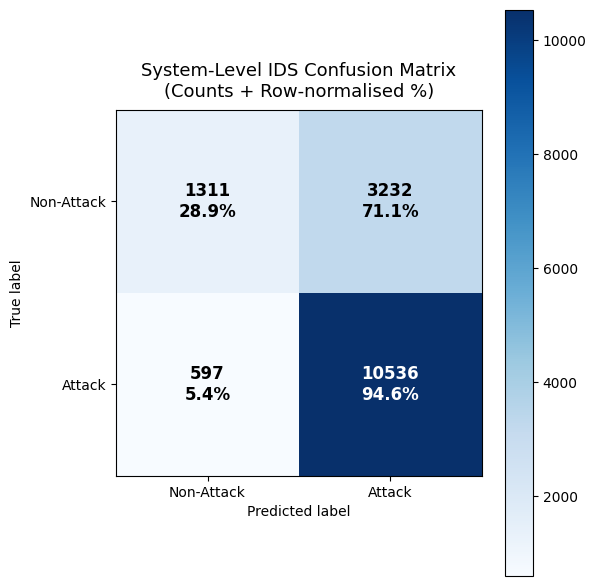

In [26]:
# ============================================================
# 6. System-Level Binary IDS Performance (TEST SET)
# ============================================================
# Purpose:
# - Evaluate the hierarchical IDS as a binary security system
# - Ignore internal routing; assess final Attack vs Non-Attack decision
# - Treat the hierarchy as a black-box IDS

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# ------------------------------------------------------------
# Predictions
# ------------------------------------------------------------

y_pred = results_df["Final_binary"].values

# ------------------------------------------------------------
# Metrics (Attack = 1 is positive class)
# ------------------------------------------------------------

acc  = accuracy_score(is_attack_test, y_pred)
prec = precision_score(is_attack_test, y_pred, pos_label=1)
rec  = recall_score(is_attack_test, y_pred, pos_label=1)
f1   = f1_score(is_attack_test, y_pred, pos_label=1)

print("System-Level IDS Metrics (TEST SET)")
print(f" Accuracy : {acc:.4f}")
print(f" Precision: {prec:.4f}")
print(f" Recall   : {rec:.4f}")
print(f" F1-score : {f1:.4f}")

# ------------------------------------------------------------
# Confusion Matrix (Counts + Row %)
# ------------------------------------------------------------

cm = confusion_matrix(is_attack_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non-Attack", "Attack"]
)
disp.plot(ax=ax, cmap="Blues", colorbar=True)

# Remove default annotations
for text in ax.texts:
    text.remove()

# Add custom annotations (COUNT + ROW %)
for i in range(2):
    for j in range(2):
        count = cm[i, j]
        row_sum = cm[i].sum()
        pct = 100 * count / row_sum if row_sum > 0 else 0

        ax.text(
            j, i,
            f"{count}\n{pct:.1f}%",
            ha="center",
            va="center",
            fontsize=12,
            fontweight="bold",
            color="white" if count > cm.max() * 0.5 else "black"
        )

ax.set_title(
    "System-Level IDS Confusion Matrix\n(Counts + Row-normalised %)",
    fontsize=13,
    pad=10
)

plt.tight_layout()
plt.show()

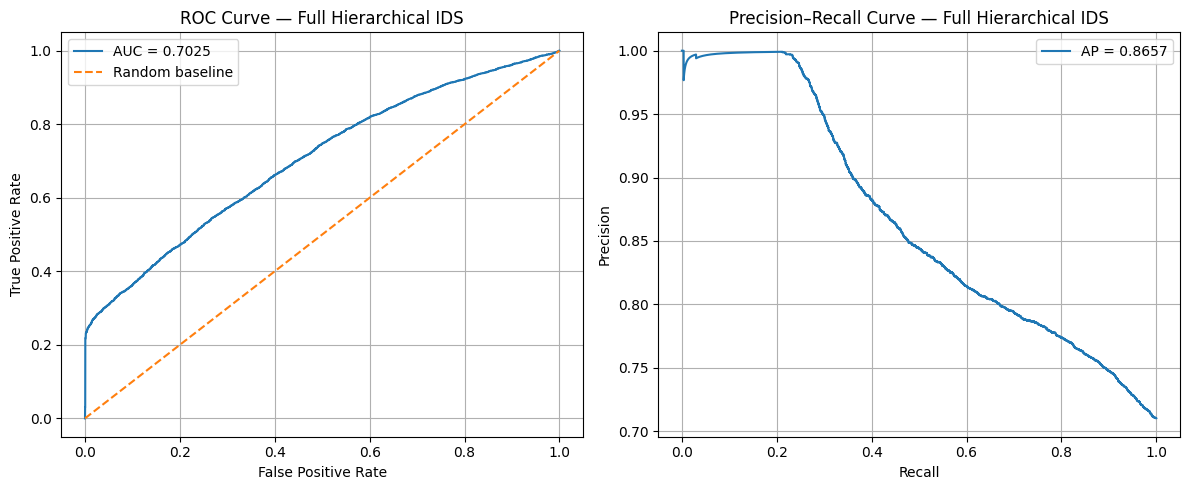

In [29]:
# ============================================================
# 6.2 ROC + Precision–Recall (SIDE-BY-SIDE)
# ============================================================

from sklearn.metrics import (
    roc_curve, auc,
    precision_recall_curve, average_precision_score
)

# True labels
y_true = is_attack_test.astype(int)

# System score (M1 confidence)
y_score = results_df["M1_conf"].values

# ------------------------------------------------------------
# Compute metrics
# ------------------------------------------------------------
fpr, tpr, _ = roc_curve(y_true, y_score)
roc_auc = auc(fpr, tpr)

precision, recall, _ = precision_recall_curve(y_true, y_score)
avg_precision = average_precision_score(y_true, y_score)

# ------------------------------------------------------------
# Plot side-by-side
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ===================== ROC =====================
axes[0].plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
axes[0].plot([0, 1], [0, 1], linestyle="--", label="Random baseline")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve — Full Hierarchical IDS")
axes[0].legend()
axes[0].grid(True)

# ===================== PR ======================
axes[1].plot(recall, precision, label=f"AP = {avg_precision:.4f}")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision–Recall Curve — Full Hierarchical IDS")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [21]:
# ============================================================
# 7. Routing & Fallback Path Statistics (System-Level)
# ============================================================
# Purpose:
# - Quantify how samples traverse the hierarchical IDS
# - Show distribution across all routing outcomes
# - Verify SAFE fallback activation and confirmed attack rate
# - This analysis is system-level (not model-level)

# ------------------------------------------------------------
# Full routing-path distribution
# ------------------------------------------------------------
routing_stats = (
    results_df["Decision"]
    .value_counts(normalize=True)
    .rename("Fraction")
    .reset_index()
    .rename(columns={"index": "Routing Path"})
)

print("Routing Path Distribution (TEST SET)")
routing_stats

# ------------------------------------------------------------
# Derived routing metrics (interpretive summaries)
# ------------------------------------------------------------
attack_path_rate = (results_df["Decision"] != "M2_DIRECT").mean()
fallback_rate = (results_df["Decision"] == "FALLBACK_TO_M2").mean()
confirmed_attack_rate = (results_df["Decision"] == "ATTACK_CONFIRMED").mean()
direct_non_attack_rate = (results_df["Decision"] == "M2_DIRECT").mean()

print("\nDerived Routing Metrics")
print(f" Attack path rate (→ M3):        {attack_path_rate:.4f}")
print(f" Fallback activation rate:       {fallback_rate:.4f}")
print(f" Confirmed attack rate:          {confirmed_attack_rate:.4f}")
print(f" Direct non-attack routing rate: {direct_non_attack_rate:.4f}")

Routing Path Distribution (TEST SET)

Derived Routing Metrics
 Attack path rate (→ M3):        0.9566
 Fallback activation rate:       0.0783
 Confirmed attack rate:          0.8783
 Direct non-attack routing rate: 0.0434


In [22]:
DI_IDS  = list(range(7,13))
RT_IDS  = list(range(15,21))
RSC_IDS = list(range(21,31)) + list(range(35,41))

def map_family(marker):
    if marker in DI_IDS:
        return "DI"
    elif marker in RT_IDS:
        return "RT"
    elif marker in RSC_IDS:
        return "RSC"
    else:
        return "NON_ATTACK"

y_family_true = y_marker.loc[X_test.index].apply(map_family).values

family_recalls = {}
for fam in ["DI","RT","RSC"]:
    mask = (y_family_true == fam)
    family_recalls[fam] = (y_pred[mask] == 1).mean() if mask.sum() else np.nan

pd.DataFrame.from_dict(family_recalls, orient="index", columns=["Recall"])


,Recall
DI,0.897948
RT,0.906376
RSC,0.967507


In [23]:
scenario_confusion = (
    pd.DataFrame({
        "marker": y_marker.loc[X_test.index].values,
        "attack_true": is_attack_test.values,
        "attack_pred": y_pred
    })
    .groupby("marker")
    .agg(
        total=("attack_true","size"),
        attack_rate_true=("attack_true","mean"),
        attack_rate_pred=("attack_pred","mean")
    )
    .sort_values("total", ascending=False)
)

scenario_confusion.head(10)


,total,attack_rate_true,attack_rate_pred
marker,,,
36,996,1.0,0.980924
41,886,0.0,0.400677
35,863,1.0,0.994206
6,680,0.0,0.883824
5,596,0.0,0.890940
4,591,0.0,0.886633
23,522,1.0,1.000000
37,517,1.0,0.864603
25,508,1.0,1.000000


### Deployment Pseudocode

INPUT: sample x

1. Compute p_attack = M1(x)

2. IF p_attack < TAU_GATE:
       y = M2(x)
       RETURN NonAttack(y)

3. ELSE:
       (c3, conf3) = M3(x)

       IF conf3 < CONF_FALLBACK AND p_attack < TAU_GATE + SAFE_MARGIN:
           y = M2(x)
           RETURN NonAttack(y)

       ELSE:
           IF c3 == DI:
               y = M4(x)
           ELSE IF c3 == RT:
               y = M5(x)
           ELSE:
               y = M6(x)

           RETURN Attack(y)


### Final Takeaway

The end-to-end evaluation confirms that the hierarchical IDS executes deterministically
with all models (M1–M6) engaged according to the designed routing logic.
The SAFE fallback mechanism activates selectively, reducing misrouted non-attacks
while preserving safety-critical attack detections.
All results reflect final system behaviour on unseen test data.
